In [1]:
import json
from scipy.interpolate import griddata
from scipy.spatial import Delaunay
from skimage.draw import polygon
import matplotlib.pyplot as plt
import numpy as np
import cv2
import imageio
from PIL import Image
import os
import glob

plt.rcParams['figure.figsize'] = (8.0, 8.0)


In [2]:

with open('data/points.json', 'r') as file:
    points = json.load(file)

# Get the average of the points
average_points = []
for i, _ in enumerate(points["im1Points"]):
    average_points.append([(points["im1Points"][i][0]+ points["im2Points"][i][0])//2, (points["im1Points"][i][1]+ points["im2Points"][i][1])//2])

average_points = np.array(average_points, dtype=np.float32)
points_me = np.array(points["im1Points"], dtype=np.float32)
points_tay = np.array(points["im2Points"], dtype=np.float32)

print(type(points_me))


<class 'numpy.ndarray'>


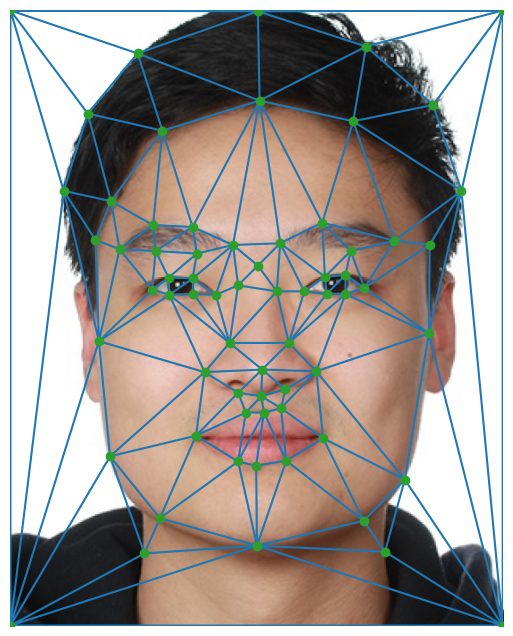

In [3]:
# show our image
me = plt.imread('data/me.jpg')
plt.imshow(me)

# Delaunay triangulation
tri_average = Delaunay(average_points)

# plot triangles and points
plt.triplot(points_me[:, 0], points_me[:, 1], tri_average.simplices)
plt.plot(points_me[:, 0], points_me[:, 1], 'o')
plt.axis('off')
plt.savefig('output/triangulation_me.jpg')
plt.show()


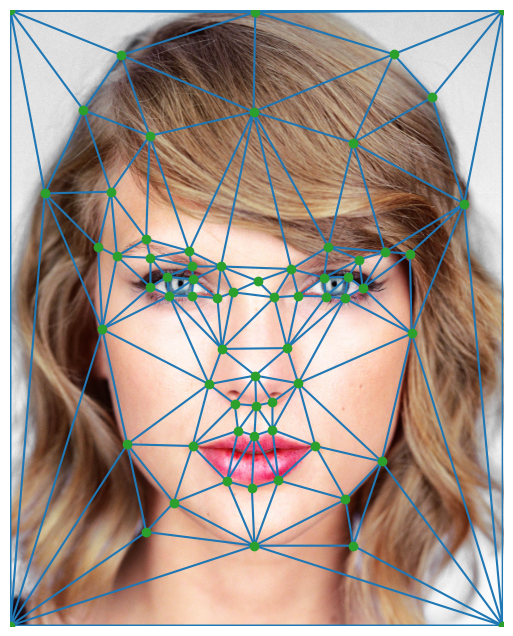

(717, 574, 3)
573.0 716.0


In [4]:
# Show taytay
tay = plt.imread('data/taytay.jpg')
plt.imshow(tay)
plt.triplot(points_tay[:, 0], points_tay[:, 1], tri_average.simplices)
plt.plot(points_tay[:, 0], points_tay[:, 1], 'o')
plt.axis('off')
plt.savefig('output/triangulation_taytay.jpg')
plt.show()
print(tay.shape)
print(np.max(points_tay[:, 0]), np.max(points_tay[:, 1]))

In [5]:
def computeAffine(tri1_pts,tri2_pts):
    # Compute the affine transformation matrix that maps points from tri1_pts to tri2_pts
    A = np.zeros((6,6))
    b = np.zeros((6,1))
    for i in range(3):
        A[i*2] = [tri1_pts[i][0],tri1_pts[i][1],1,0,0,0]
        A[i*2 + 1] = [0,0,0,tri1_pts[i][0],tri1_pts[i][1],1]
        b[i*2] = tri2_pts[i][0]
        b[i*2 + 1] = tri2_pts[i][1]
    x = np.linalg.solve(A,b)
    x = np.append(x,[0,0,1])
    return x.reshape(3,3)

# Lets get our affine transformations
affine_trans_me2av = []
affine_trans_tay2av = []
affine_trans_me2tay = []
r1 = []

for i in tri_average.simplices:
    affine_trans_me2av.append(computeAffine(points_me[i], average_points[i]))
    affine_trans_tay2av.append(computeAffine(points_tay[i], average_points[i]))
    affine_trans_me2tay.append(computeAffine(points_me[i], points_tay[i]))


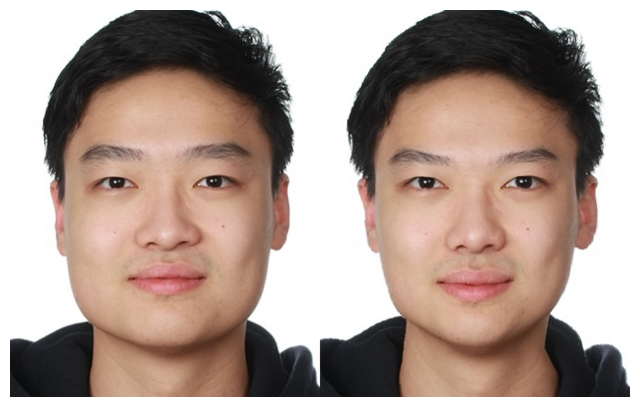

In [6]:
# Notes:
# image has shape (717, 574, 3), so the coordinates of the points are (x, y) = (574, 717) x being the width and y the height
# Warp both faces
def get_midwayface(average_triangles, average_points, original, affine_trans_original2av):
    # Create the empty midway face
    midface = np.zeros(original.shape, dtype=np.uint8)
    # Loop through all the triangles
    for i in range(len(average_triangles.simplices)):
        polygoncorners = average_points[average_triangles.simplices[i]] # is in the form [x,y], [x,y], [x,y]
        # xx, yy contain all the pixels
        xx, yy = polygon(polygoncorners[:, 0], polygoncorners[:, 1])
        midfacepoints = np.vstack([xx, yy])
        # inverse affine transformation to get the pixels from the original face
        # I'm using nearest neighbor interpolation here to save on compute time
        originalfacepoints = np.linalg.inv(affine_trans_original2av[i])@np.array([midfacepoints[0], midfacepoints[1], np.ones(midfacepoints.shape[1])])
        # pixels are whole int numbers
        originalfacepoints = np.round(originalfacepoints).astype(int)
        midface[midfacepoints[1], midfacepoints[0]] = original[originalfacepoints[1], originalfacepoints[0]]
    return midface

midface_me = get_midwayface(tri_average, average_points, me, affine_trans_me2av)

plt.axis('off')
plt.imshow(np.hstack([me, midface_me]))
plt.imsave('output/midface_me.jpg', midface_me)
plt.show()fasdf



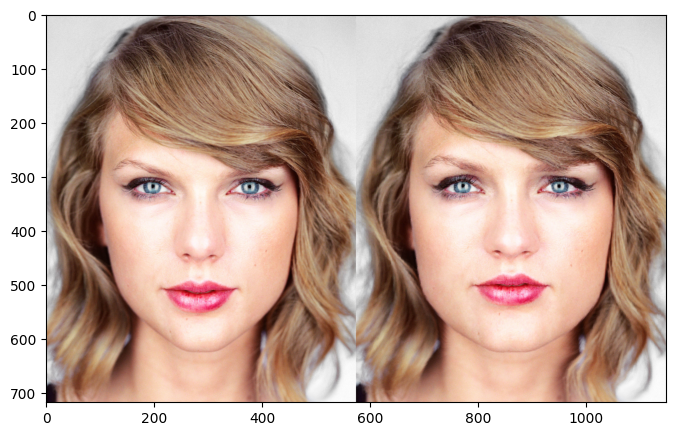

In [7]:
midface_tay = get_midwayface(tri_average, average_points, tay, affine_trans_tay2av)
plt.imshow(np.hstack([tay, midface_tay]))
plt.imsave('output/midface_tay.jpg', midface_tay)
plt.show()

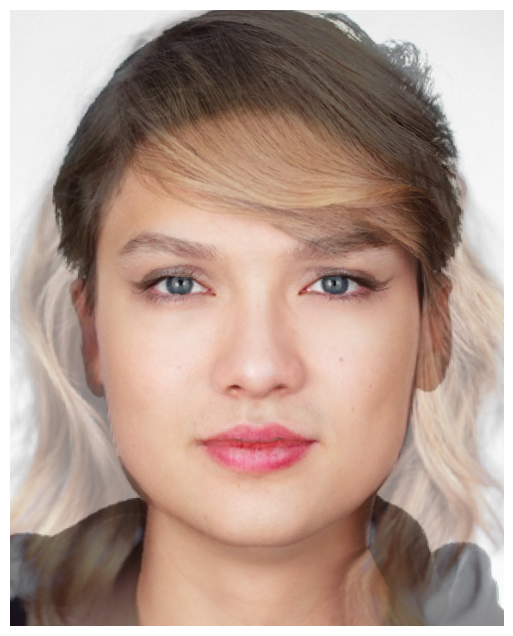

In [8]:
# We blended the images plenty in the previous 2 projects, I'm just going to use the cv2 funciton this time
midface_final = cv2.addWeighted(midface_tay, 0.5, midface_me, 0.5, 0.0)
plt.axis('off')
plt.imshow(midface_final)
plt.imsave('output/midface_final.jpg', midface_final)
plt.show()

In [9]:
# Part 3
# We are going to create the following function:
def morph(im1, im2, im1_pts, im2_pts, tri, warp_frac, dissolve_frac):
    #  This is just everything above written down together
    frac_points = []
    for i, _ in enumerate(im1_pts):
        frac_points.append([(im1_pts[i][0] * (1-warp_frac) + im2_pts[i][0] * warp_frac) // 1, (im1_pts[i][1] * (1-warp_frac) + im2_pts[i][1] * warp_frac) // 1])
    frac_points = np.array(frac_points, dtype=np.float32)
    points_im1 = np.array(im1_pts, dtype=np.float32)
    points_im2 = np.array(im2_pts, dtype=np.float32)

    if tri == "Delaunay":
        tri_frac = Delaunay(frac_points)
    else:
        raise ValueError("tri must be Delaunay")
    affine_trans_im12frac = []
    affine_trans_im22frac = []
    for i in tri_frac.simplices:
        affine_trans_im12frac.append(computeAffine(points_im1[i], frac_points[i]))
        affine_trans_im22frac.append(computeAffine(points_im2[i], frac_points[i]))


    
    midface_im1 = get_midwayface(tri_frac, frac_points, im1, affine_trans_im12frac)
    midface_im2 = get_midwayface(tri_frac, frac_points, im2, affine_trans_im22frac)
    midface_final = cv2.addWeighted(midface_im1, (1-dissolve_frac), midface_im2, dissolve_frac, 0.0)
    return midface_final


In [10]:
# We want 45 frames between 0 and 1
zerotoone = np.linspace(0, 1, 45)
for i, frac in enumerate(zerotoone):
    plt.imsave(f'output/morphed_{i}.png', morph(me, tay, points["im1Points"], points["im2Points"], "Delaunay", frac, frac))
frames = [f'output/morphed_{i}.png' for i, _ in enumerate(zerotoone)]
images = [Image.open(frame) for frame in frames]
imageio.mimsave('output/the_morph_sequence.gif', images, fps=30, loop=1)

In [11]:
# In Part 4 we are going to calculate the mean face of a population
def get_points_from_asf(filepath):
    points = []
    
    with open(filepath, 'r') as file:
        lines = file.readlines()
        for line in lines:
            if line.strip() and not line.startswith('#'):
                # Split the line into components
                parts = line.split()
                # Only take the lines that are about the points, these lines have more than 5 parts
                if len(parts) >= 5:
                    # get the x and y relative coordinates and multiply them by the image size
                    x_rel = float(parts[2]) * 640
                    y_rel = float(parts[3]) * 480
                    # Append as a tuple (x, y) to the points list
                    points.append([x_rel, y_rel])
        # Add the corners of the image
        points.append([0, 0])
        points.append([639, 0])
        points.append([0, 479])
        points.append([639, 479])
    points_array = np.array(points, dtype=float)
    return points_array

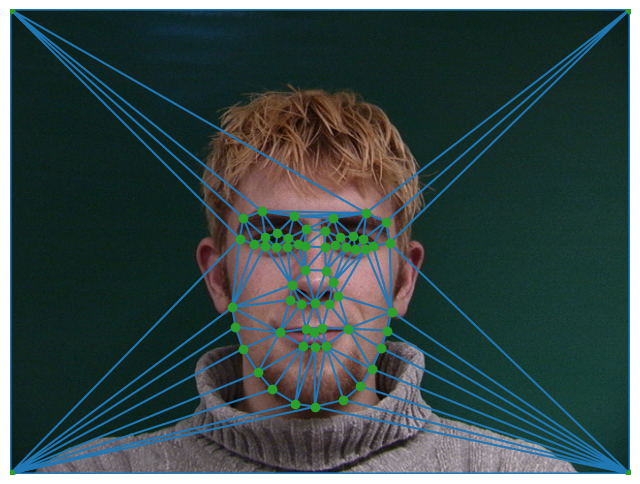

(480, 640, 3)
639.0 479.0


In [12]:
# show our image
points_dane_one = get_points_from_asf('data/face_data/04-1m.asf')
one_dane = plt.imread('data/face_data/04-1m.bmp')
plt.imshow(one_dane)
# Delaunay triangulation
tri_dane_one = Delaunay(points_dane_one)

# plot triangles and points
plt.triplot(points_dane_one[:, 0], points_dane_one[:, 1], tri_dane_one.simplices)
plt.plot(points_dane_one[:, 0], points_dane_one[:, 1], 'o')
plt.axis('off')
plt.show()
print(one_dane.shape)
print(np.max(points_dane_one[:, 0]), np.max(points_dane_one[:, 1]))

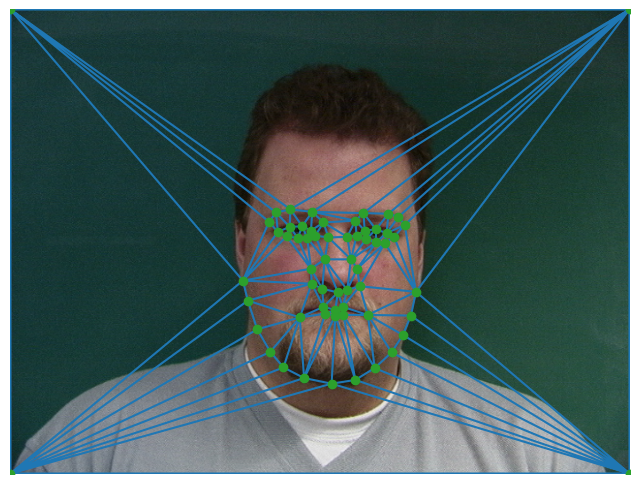

In [13]:
# show our image
points_dane_two = get_points_from_asf('data/face_data/05-1m.asf')
one_dane = plt.imread('data/face_data/05-1m.bmp')
plt.imshow(one_dane)

# Delaunay triangulation
tri_dane_two = Delaunay(points_dane_two)

# plot triangles and points
plt.triplot(points_dane_two[:, 0], points_dane_two[:, 1], tri_dane_two.simplices)
plt.plot(points_dane_two[:, 0], points_dane_two[:, 1], 'o')
plt.axis('off')
plt.show()


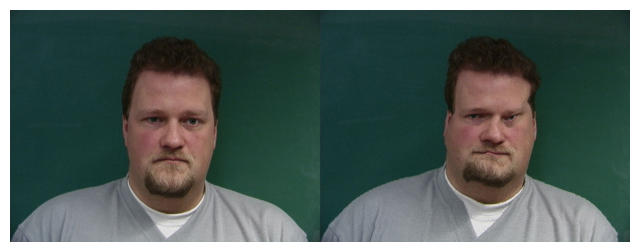

In [14]:
affine_trans_2danes = []
for i in tri_dane_two.simplices:
    affine_trans_2danes.append(computeAffine(points_dane_one[i], points_dane_two[i]))
midface_danes = get_midwayface(tri_dane_two, points_dane_two, one_dane, affine_trans_2danes)
plt.axis('off')
plt.imshow(np.hstack([one_dane, midface_danes]))
plt.show()

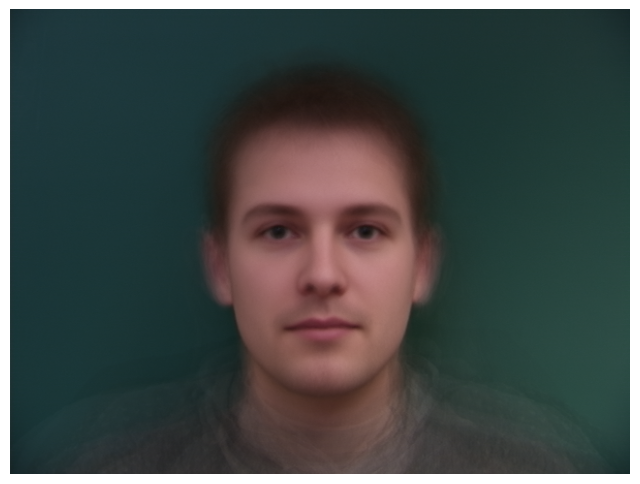

In [15]:
# Lets get the average face of the population
danish_points_average = np.array([])
for i in range(4, 41):
    pattern = os.path.join('data/face_data/', f'{i:02}*.asf')  # Format the numbers to 2 digits
    danish_files = glob.glob(pattern)
    dane_points = get_points_from_asf(danish_files[0])
    if danish_points_average.size == 0:
        danish_points_average = dane_points
    else:
        danish_points_average += dane_points

# Now we have the danish point average
danish_points_average = danish_points_average//37
# Can create our delaunay triangulation with that
tri_danish_ave = Delaunay(danish_points_average)

average_face = np.array([])
start = 4
stop = 40
for i in range(start, stop):
    pattern = os.path.join('data/face_data/', f'{i:02}*.asf')  # Format the numbers to 2 digits
    danish_files = glob.glob(pattern)
    dane_points = get_points_from_asf(danish_files[0])
    affine_trans_dane2avdane = []
    for j in tri_danish_ave.simplices:
        affine_trans_dane2avdane.append(computeAffine(dane_points[j], danish_points_average[j]))
    one_dane = plt.imread(danish_files[0][:-3]+'bmp')
    midface_dane = get_midwayface(tri_danish_ave, danish_points_average, one_dane, affine_trans_dane2avdane)
    plt.axis('off')
    plt.imshow(np.hstack([one_dane, midface_dane]))
    # Here we save all the danish faces warped into the average danish face
    plt.imsave(f'output/danes/dane{i:02}.jpg', np.hstack([one_dane, midface_dane]))
    if average_face.size == 0:
        average_face = midface_dane/255
    else:
        average_face += midface_dane/255
average_face = average_face/(stop-start)
plt.imsave(f'output/danes/average_dane.jpg', average_face)
plt.imshow(average_face)
plt.show()


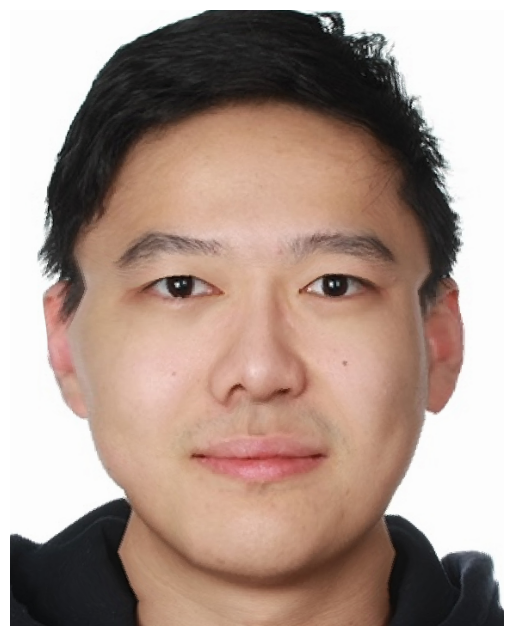

In [66]:
# Now lets warp my face to the average geometry
with open('data/average_dane_points.json', 'r') as file:
    points_me_dane = json.load(file)

average_dane = plt.imread('data/average_dane.jpg')

measaveragedane = morph(me, average_dane, points_me_dane["im2Points"], points_me_dane["im1Points"], 'Delaunay', 0.99, 0.01)
plt.axis('off')
plt.imshow(measaveragedane)
plt.imsave('output/me_with_danish_shape.jpg', measaveragedane)
plt.show()


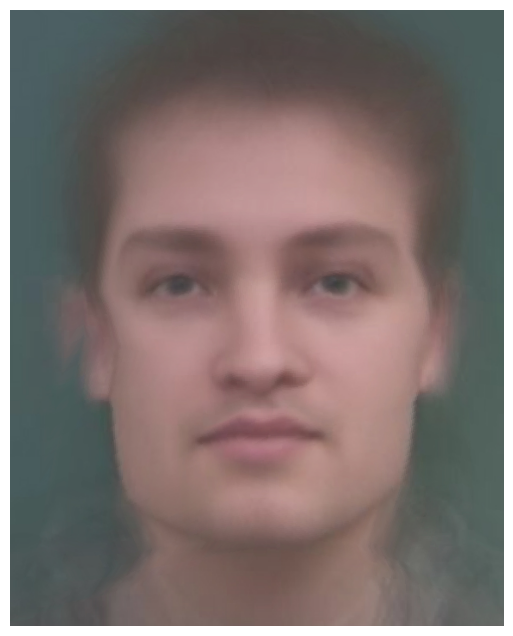

In [67]:
# and the average geometry to my face
measaveragedane = morph(me, average_dane, points_me_dane["im2Points"], points_me_dane["im1Points"], 'Delaunay', 0.01, 0.99)
plt.axis('off')
plt.imshow(measaveragedane)
plt.imsave('output/dane_with_my_shape.jpg', measaveragedane)
plt.show()

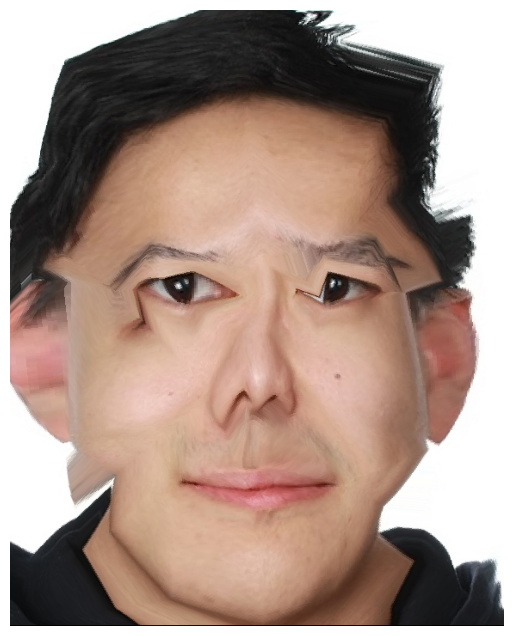

In [68]:
# Part 5: Caricatures: Extrapolating from the Mean

measaveragedane = morph(me, average_dane, points_me_dane["im2Points"], points_me_dane["im1Points"], 'Delaunay', 1.5, 0)
plt.imsave('output/me_with_danish_shape1_5.jpg', measaveragedane)
measaveragedane = morph(me, average_dane, points_me_dane["im2Points"], points_me_dane["im1Points"], 'Delaunay', 2, 0)
plt.imsave('output/me_with_danish_shape2.jpg', measaveragedane)
measaveragedane = morph(me, average_dane, points_me_dane["im2Points"], points_me_dane["im1Points"], 'Delaunay', 2.4, 0)
plt.imsave('output/me_with_danish_shape2_4.jpg', measaveragedane)
plt.axis('off')
plt.imshow(measaveragedane)
plt.show()

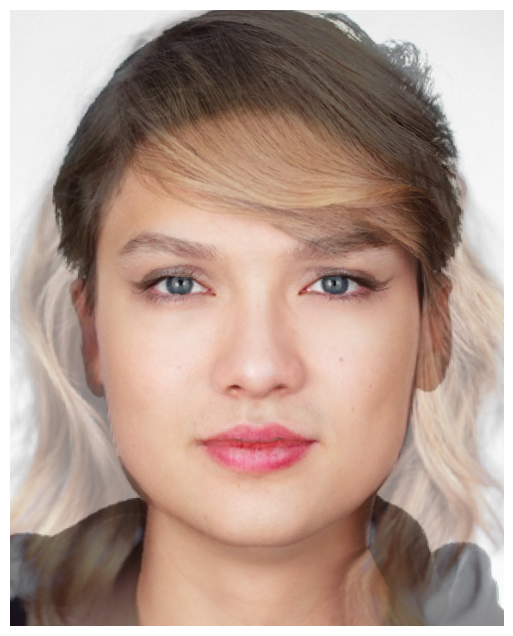

In [77]:
# Gender Change
genderchange = morph(me, tay, points["im1Points"], points["im2Points"], "Delaunay", 0.5, 0)
plt.imsave('output/genderchange_shape_only.jpg', genderchange)
genderchange = morph(me, tay, points["im1Points"], points["im2Points"], "Delaunay", 0, 0.5)
plt.imsave('output/genderchange_appearance_only.jpg', genderchange)
genderchange = morph(me, tay, points["im1Points"], points["im2Points"], "Delaunay", 0.5, 0.5)
plt.imsave('output/genderchange_both.jpg', genderchange)
plt.axis('off')
plt.imshow(genderchange)
plt.show()